# Проект "Данные о продажах шоколада за 2023-2024 годы."

***Цель:*** Определить типичный портрет клиента: возраст, пол, город покупки, продукция и т.д. 

***Задачи:*** Знакомство, предобработка и анализ данных датасета "Данные о продажах шоколада за 2023-2024 годы." с платвормы `kaggle`.

### Содержимое проекта 
---
1. [Загрузка данных и знакомство с ними](#section1)
2. [Предобработка данных](#section2)
3. [Исследовательский анализ данных](#section3)
4. [Итоговый вывод](#section4)

<a id='section1'></a>
### 1. Загрузка данных и знакомство с ними

In [22]:
# Импортируем библиотеки
import pandas as pd
import numpy as np 

# Импортируем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

#Устанавливаем библиотеку phik
!pip install phik -q

# Импортируем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

# Импортируем библиотеку для оформления
from IPython.display import display, Markdown

Произведем загрузку, ранее скачанных данных с платформы kaggle (рассположенных по ссылке https://www.kaggle.com/datasets/ssssws/chocolate-sales-dataset-2023-2024/data) и первичное знакомство.

In [23]:
#Загружаем файл с данными о продажах
sales = pd.read_csv(r"C:\Users\Администратор\Desktop\kaggle\chocolate\sales.csv", sep=',')
display(Markdown('**Датафрейм с данными о продажах**'))
display(sales.info(), sales.head())

#Загружаем файл с данными о продукции
products = pd.read_csv(r"C:\Users\Администратор\Desktop\kaggle\chocolate\products.csv", sep=',')
display("-----------------------------------------------------------------------")
display(Markdown('**Датафрейм с данными о продукции**'))
display(products.info(), products.head())

#Загружаем файл с данными о магазинах
stores = pd.read_csv(r"C:\Users\Администратор\Desktop\kaggle\chocolate\stores.csv", sep=',')
display("-----------------------------------------------------------------------")
display(Markdown('**Датафрейм с данными о магазинах**'))
display(stores.info(), stores.head())

#Загружаем файл с данными о клиентах
customers = pd.read_csv(r"C:\Users\Администратор\Desktop\kaggle\chocolate\customers.csv", sep=',')
display("-----------------------------------------------------------------------")
display(Markdown('**Датафрейм с данными о клиентах**'))
display(customers.info(), customers.head())

#Загружаем файл с данными о календаре
calendar = pd.read_csv(r"C:\Users\Администратор\Desktop\kaggle\chocolate\calendar.csv", sep=',')
display("-----------------------------------------------------------------------")
display(Markdown('**Датафрейм с данными о календаре**'))
display(calendar.info(), calendar.head())

**Датафрейм с данными о продажах**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB


None

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


'-----------------------------------------------------------------------'

...

'-----------------------------------------------------------------------'

**Датафрейм с данными о календаре**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         731 non-null    object
 1   year         731 non-null    int64 
 2   month        731 non-null    int64 
 3   day          731 non-null    int64 
 4   week         731 non-null    int64 
 5   day_of_week  731 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 34.4+ KB


None

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


Данные являются полными без пропусков. 

***Описание***: 
Данные состоят из следующих датафреймов: 
1. `sales` - Содержит данные о продажах на уровне отдельных транзакций. Состоит из 100 000 строк и 11 столбцов
- `order_id` – Уникальный идентификатор заказа
- `order_date` – Дата покупки
- `product_id` – Идентификатор продукта
- `store_id` – Идентификатор магазина
- `customer_id` – Идентификатор клиента
- `quantity` – Количество проданных товаров
- `unit_price` – Цена за единицу
- `discount` – Скидка применена к транзакции
- `revenue` – Общая выручка после скидки
- `cost` – Ориентировочная стоимость продукции
- `profit` – Прибыль от сделки

2. `products` - Информация о шоколадных изделиях. Состоит из 200 строк и 6 столбцов
- `product_id` – Идентификатор продукта
- `product_name` – Название продукта
- `brand` – Бренд
- `category` – Категория
- `cocoa_percent` – Процент содержания какао
- `weight_g` – вес в граммах

3. `stores` – Информация о розничных магазинах. Состоит из 100 строк и 5 столбцов
- `store_id` – Идентификатор магазина
- `store_name` – Название магазина
- `city` – Город
- `country` – Страна
- `store_type` – Тип магазина

4. `customers` – Демографические данные клиентов. Состоит из 50 000 строк и 5 столбцов
- `customer_id` – – Идентификатор клиента
- `age` – Возраст
- `gender` – Пол
- `loyalty_member` – Лояльность
- `join_date` – Дата присоединения

5. `calendar` - Календарная таблица полезна для анализа во времени. Состоит из 731 строк и 7 столбцов
- `date` - Дата
- `year` - Год
- `month` - Месяц
- `day` - День
- `week` - Неделя
- `day_of_week` - День недели

Отдельно стоит рассмотреть `stores`, т.к. есть несоответствия города и страны

In [3]:
# Сгруппируем данные по стране и городу
group_stores = stores.groupby(['country', 'city'])['store_id'].count()
group_stores

country    city     
Australia  Berlin       2
           London       2
           Melbourne    1
           New York     2
           Paris        2
           Sydney       2
           Toronto      4
Canada     London       4
           Melbourne    3
           New York     2
           Paris        3
           Sydney       2
           Toronto      6
France     Berlin       3
           London       3
           Melbourne    1
           New York     2
           Paris        2
           Sydney       2
           Toronto      4
Germany    Berlin       2
           London       3
           Melbourne    1
           New York     2
           Paris        2
           Sydney       1
           Toronto      1
UK         Berlin       2
           London       3
           Melbourne    2
           New York     3
           Paris        5
           Sydney       2
           Toronto      2
USA        Berlin       1
           London       1
           Melbourne    4
           New Yo

Города в разных странах повторяются и не соответствуют действительности, возможно страна указана, как страна учредителя магазина по франшизе, а не места расположения. Данный столбец с достоверностью использовать невозможно. В таком случае принимаю решение не использовать столбец со страной в дальнейшем анализе данных.

<a id='section2'></a>
### 2.Предобработка данных

Для дальнейшей работы объединим имеющиеся датафреймы

In [4]:
# Объединяем датафреймы
df = (sales
    .merge(products, on = 'product_id', how = 'left')
    .merge(stores, on = 'store_id', how = 'left')
    .merge(customers, on = 'customer_id', how = 'left')
    .merge(calendar, left_on = 'order_date', right_on = 'date',  how = 'left')
     )

# удаляем дублирующий столбец date
df = df.drop(columns = 'date')

# Выводим все столбцы
pd.set_option('display.max_columns', None)  
display(df.head(), df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        1000000 non-null  object 
 1   order_date      1000000 non-null  object 
 2   product_id      1000000 non-null  object 
 3   store_id        1000000 non-null  object 
 4   customer_id     1000000 non-null  object 
 5   quantity        1000000 non-null  int64  
 6   unit_price      1000000 non-null  float64
 7   discount        1000000 non-null  float64
 8   revenue         1000000 non-null  float64
 9   cost            1000000 non-null  float64
 10  profit          1000000 non-null  float64
 11  product_name    990236 non-null   object 
 12  brand           990236 non-null   object 
 13  category        990236 non-null   object 
 14  cocoa_percent   990236 non-null   float64
 15  weight_g        990236 non-null   float64
 16  store_name      1000000 non-null  obj

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70.0,200.0,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,Chocolate Store 65,New York,Australia,Retail,63,Female,1,2023-07-03,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,Chocolate Store 78,London,UK,Airport,35,Male,1,2023-10-09,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,Chocolate Store 88,Toronto,USA,Retail,37,Female,1,2023-05-30,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,Chocolate Store 54,London,Canada,Online,57,Female,0,2021-08-20,2024,9,24,39,1


None

После объединения мы можем наблюдать, что появились пропуски. Т.к пропуск составляет менее 1% строк, то чтобы не искажать данные эти строки будут удалены.

Столбцы cocoa_percent и weight_g, принявшие формат float из-за пропусков необходимо преобразовать к int

In [5]:
# Перед обработкой датафреймов расчитываем вес датафрейма
start_mem = df.memory_usage(deep=True).sum() / 1024**2

print(f"Начальный вес датафреймов: {start_mem:.2f} MB")

# Удаляем пропуски
df = df.dropna()
print("Оставшееся количество строк:", df.shape[0])

Начальный вес датафреймов: 880.93 MB
Оставшееся количество строк: 990236


In [6]:
# Произведем подсчет количества дубликатов 
full_duplicated = df.duplicated().sum()
duplicated = df.duplicated('order_id').sum()

# Выводим результат
print(f"В датфрейме содержится: {full_duplicated} полных дубликатов")
print(f"В датфрейме содержится: {duplicated} дубликатов по столбцу 'order_id'")

В датфрейме содержится: 0 полных дубликатов
В датфрейме содержится: 0 дубликатов по столбцу 'order_id'


In [7]:
# произведем преобразование данных

# Формируем список столбцов с типом данных datetime64[ns]
columns_date = ['order_date','join_date']
# Понижаем разряд данных 
for col in columns_date:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')
print(f"Преобразовано {len(columns_date)} столбцов datetime64[ns]")

# Определяем список столбцов с типом данных float64
columns_float = df.select_dtypes(include='float64').columns
# Понижаем разряд данных 
for col in columns_float:
    df[col] = pd.to_numeric(df[col], downcast='float')
print(f"Преобразовано {len(columns_float)} столбцов float64")

# Определяем список столбцов с типом данных int64 и добавляем два названия столбцов 'cocoa_percent' и 'weight_g'
columns_int = list(df.select_dtypes(include='int64').columns) + ['cocoa_percent', 'weight_g']
# Понижаем разряд данных 
for col in columns_int:
    df[col] = pd.to_numeric(df[col], downcast='integer')
print(f"Преобразовано {len(columns_int)} столбцов int64")

# Cтолбец loyalty_member преобразуем в тип данных bool
df['loyalty_member'] = df['loyalty_member'].astype('bool')

Преобразовано 2 столбцов datetime64[ns]
Преобразовано 7 столбцов float64
Преобразовано 10 столбцов int64


In [8]:
# # Расчитаем общий конечный вес датафреймов и выведем разницу с начальными данными
end_mem = df.memory_usage(deep=True).sum() / 1024**2
savings = (1 - end_mem / start_mem) * 100

print(f"Начальный вес датафреймов: {start_mem:.2f} MB")
print(f"Финальный вес датафрейма: {end_mem:.2f} MB")
print(f"Экономия памяти: {savings:.1f}%")

Начальный вес датафреймов: 880.93 MB
Финальный вес датафрейма: 701.20 MB
Экономия памяти: 20.4%


<a id='section3'></a>
### 3. Исследовательский анализ данных

Произведем проверку распределения клиентов по полу и возрасту, для построения портрета клиентов.

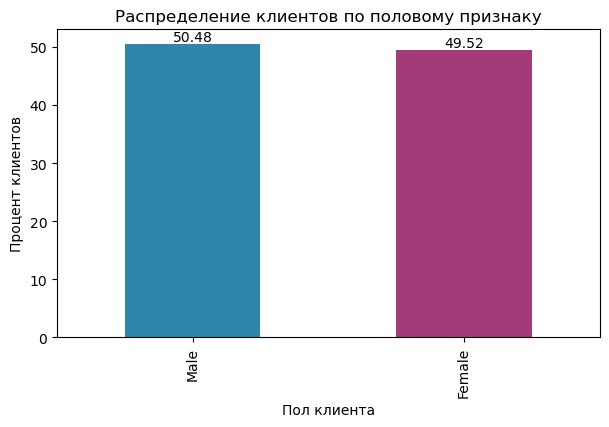

In [9]:
# группируем данные по столбцу и подсчитываем долю 
gender = (customers['gender'].value_counts(normalize=True)) * 100

# Построим график столбчатой диаграммы
ax = gender.plot(kind = 'bar',
            color = ['#2E86AB', '#A23B78'],
            legend=False, 
            figsize=(7, 4)
           )

# Подписываем каждую колонку числом сверху
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')

# Настраиваем оформление графика
plt.title('Распределение клиентов по половому признаку')
plt.xlabel('Пол клиента')
plt.ylabel('Процент клиентов')

plt.show()

<IPython.core.display.Markdown object>
count    50000.000000
mean        44.026100
std         15.328333
min         18.000000
25%         31.000000
50%         44.000000
75%         57.000000
max         70.000000
Name: age, dtype: float64


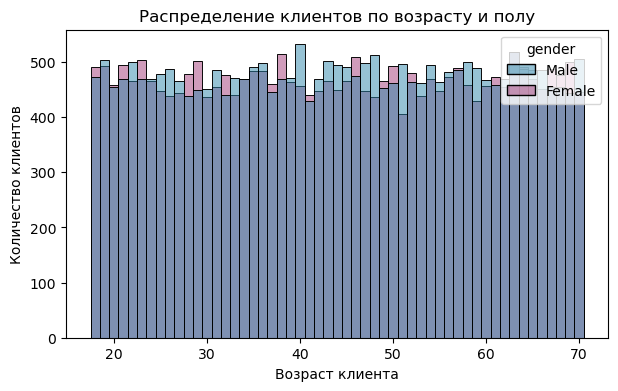

In [10]:
# Выведем обзор данных по столбцу 'age'
age_describe = customers['age'].describe()
print(Markdown('**Выведем данные по столбцу "age"**'))
print(age_describe)

# Построим график гистограммы
plt.figure(figsize = (7, 4))
gender_colors = {'Male': '#2E86AB', 'Female': '#A23B78'}

sns.histplot(
    data=customers,
    x='age',
    hue='gender',
    discrete=True,
    palette=gender_colors
)

# Настраиваем оформление графика
plt.title('Распределение клиентов по возрасту и полу')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество клиентов')

plt.show()

Из графиков мы можем наблюдать, что пол клиентов распределен примерно поровну, мужчин немного больше.  
Средний возраст и медиана почти идентичны, что указывает на равномерное распределение возраста от 18 лет до 70 лет, что мы и видим на гистограмме, нет аномально больших или маленьких значений.
Пиком клиентов мужского пола является возраст 40 лет, пиком клиентов женщинского пола - 38 лет.  

Для дальнейшего анальза проверим взаимосвязь между данными, влияет ли пол и возраст на лояльность, а также влияние выручки на иные показатели. 

interval columns not set, guessing: ['quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'cocoa_percent', 'weight_g', 'age']


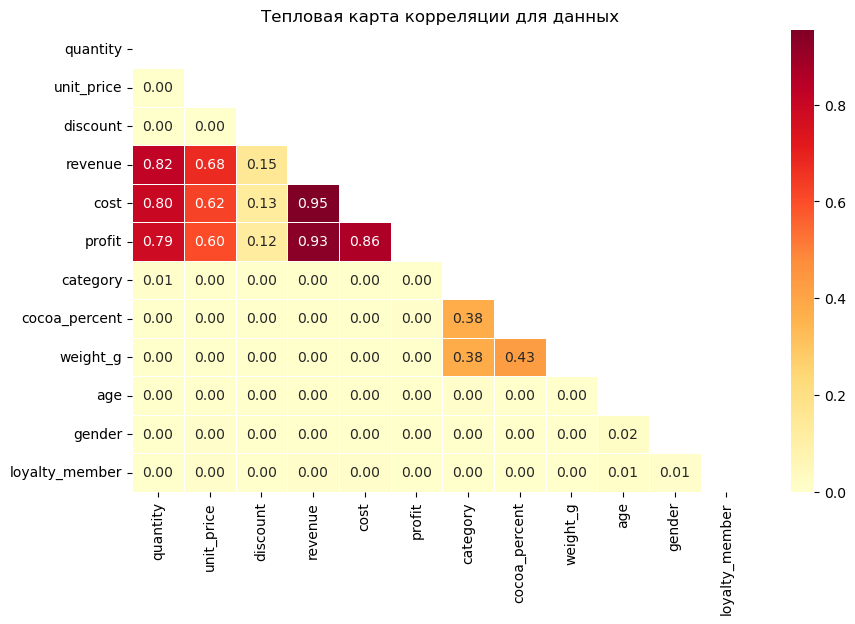

In [11]:
# Создаем список столбцов
columns = (['quantity', 'unit_price', 'discount',	'revenue', 'cost', 'profit', 
            'category', 'cocoa_percent', 'weight_g', 'age', 'gender', 'loyalty_member'
])

# Вычисляем матрицу коэффициентов корреляции Phi_K 
correlation_matrix = df[columns].phik_matrix()

# Создаём маску: True в верхней части, False в нижней
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Строим тепловую карту
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='YlOrRd', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=True # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта корреляции для данных ')

plt.show()

Мы можем наблюдать взаимосвязь выручки, количества, цены за единицу товара и ориентировочной стоимостью продукции и прибылью, что является логичным. Также мы видим, что влияние скидки на выручку довольно маленькое, это может указывать на то, что скидки либо не приводят к существенному росту продаж, либо компенсируется другими факторами.

Есть умеренная взаимосвязь между категорией, процентом какао и весом, что также является логичной взаимосвязью.

Кроме того, мы видим отсутствие существенной связи возраста, пола и лояльности как между собой, так и на иные данные. Отдельно воздействие лояльности на выручку проверяться не будет, т.к. нет информации каким образом определялась лояльность(карты, членство или поставление по количеству заказов)

**Проверим общие показатели о продажах шоколада за 2023-2024 годы.**

In [12]:
summary_dict = {
    'Количество заказов'   : f"{df['order_id'].count():,}".replace(',', ' '),
    'Количество проданных товаров'    : f"{df['quantity'].sum():,}".replace(',', ' '),
    'Выручка'   : f"${df['revenue'].sum():,.2f}".replace(',', ' '),
    'Затраты'   : f"${df['cost'].sum():,.2f}".replace(',', ' '),
    'Прибыль'   : f"${df['profit'].sum():,.2f}".replace(',', ' '),
    'Уникальные клиенты'   : f"{df['customer_id'].nunique():,}".replace(',', ' '),
    'Средний чек заказа'   : f"${df['revenue'].sum()/df['order_id'].count():,.2f}".replace(',', ' ')
}

# Создаем итоговую таблицу
summary_df = pd.DataFrame.from_dict(summary_dict, orient='index', columns=['Значение']).T

# Выводим результат
display(Markdown('**Данные о продажах шоколада за 2023-2024 годы**'))

summary_df.style.set_table_styles([
    {
        'selector': 'th, td',
        'props': [
            ('background-color', 'seashell'),
            ('color', '#5D4037'),
            ('border', '2px solid #5D4037'),
            ('text-align', 'center')
        ]
    }
]).hide()


**Данные о продажах шоколада за 2023-2024 годы**

Количество заказов,Количество проданных товаров,Выручка,Затраты,Прибыль,Уникальные клиенты,Средний чек заказа
990 236,2 970 470,$25 238 648.00,$15 142 996.00,$10 095 642.00,50 000,$25.49


In [13]:
# Создаем столбец с месяцем и годом
df['month_year'] = df['order_date'].dt.strftime('%Y-%m')

Проверим изменение выручки и продаж по месяцам.

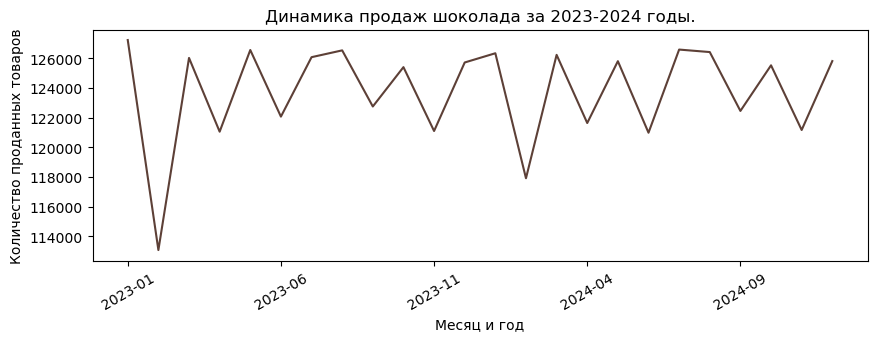

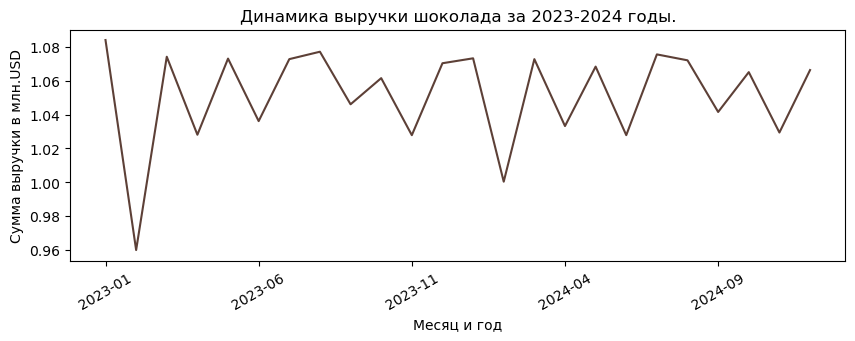

In [14]:
# Группируем данные о выручке и количестве проданных товаров по месяцам
group = df.groupby('month_year').agg(
    quantity_count = ('quantity', 'sum'),
    revenue = ('revenue', 'sum')
)

# Создадим столбец с данными о выручке, переведенными в миллионы
group['revenue_m'] = group['revenue']/1000000

# 1 Построим график линейной диаграммы динамики продаж товара
ax = group['quantity_count'].plot(kind = 'line',
                            color = '#5D4037',
                            legend=False, 
                            figsize=(10, 3),
                            rot = 30)

# Настраиваем оформление графика
plt.title('Динамика количества продаж шоколада за 2023-2024 годы.')
plt.xlabel('Месяц и год')
plt.ylabel('Количество проданных товаров')

plt.show()


# 2 Построим график линейной диаграммы динамики выручки
ax = group['revenue_m'].plot(kind = 'line',
                            color = '#5D4037',
                            legend=False, 
                            figsize=(10, 3),
                            rot = 30)

# Настраиваем оформление графика
plt.title('Динамика выручки шоколада за 2023-2024 годы.')
plt.xlabel('Месяц и год')
plt.ylabel('Сумма выручки в млн.USD')

plt.show()


На графиках видим, что средняя цена одной единицы товара оставалась практически неизменной на протяжении всего рассматриваемого периода (2023–2024 годы). Отсутствуют ценовые изменения и изменение ассортимента проданных товаров, нет указания на проведение масштабных акций. Динамика выручки полностью повторяет динамику продаж.

Пики возврастания продаж чередуются с падением продаж, как такового месяца, где продажи были больше, чем в другие не наблюдается, но рекордное снижение в феврале повторяется и на следующий год, хоть и меньше.

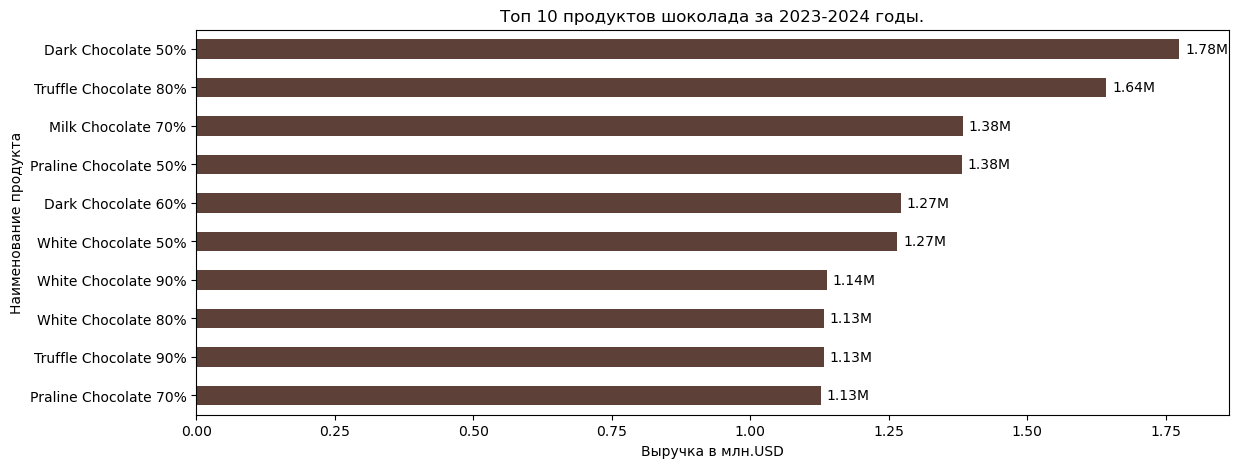

In [15]:
# Группируем данные и вычисляем сумму выручки
product_name = df.groupby('product_name').agg(revenue = ('revenue', 'sum'))

# Создаем столбец с выручкой в миллионах
product_name['revenue_m'] = product_name['revenue']/1000000

# Фильтруем данные и оставляем топ 10
product_name = product_name.sort_values(by = 'revenue_m').tail(10)

# Строим столбчатую диаграмму
ax = product_name['revenue_m'].plot(
    kind='barh',
    color = '#5D4037',
    rot=0,
    legend=False, 
    figsize=(7, 5)
)
# Добавляем подписи 
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(width + 0.01, y, f"{width:,.2f}M", va='center')

# Настраиваем оформление графика
plt.title('Топ 10 продуктов шоколада за 2023-2024 годы.')
plt.xlabel('Выручка в млн.USD')
plt.ylabel('Наименование продукта')
plt.subplots_adjust(right=1.6)
plt.show()

На графике можно наблюдать топ-10 продуктов шоколада, принесших наибольшуюю прибыль за 2023-2024 годы. Лидерами являются "Dark Chocolate 50%" и "Truffle Chocolate 80%" опережающие другие продукты на 250 тыс.долларов и более, далее идет более плавное уменьшение выручки.

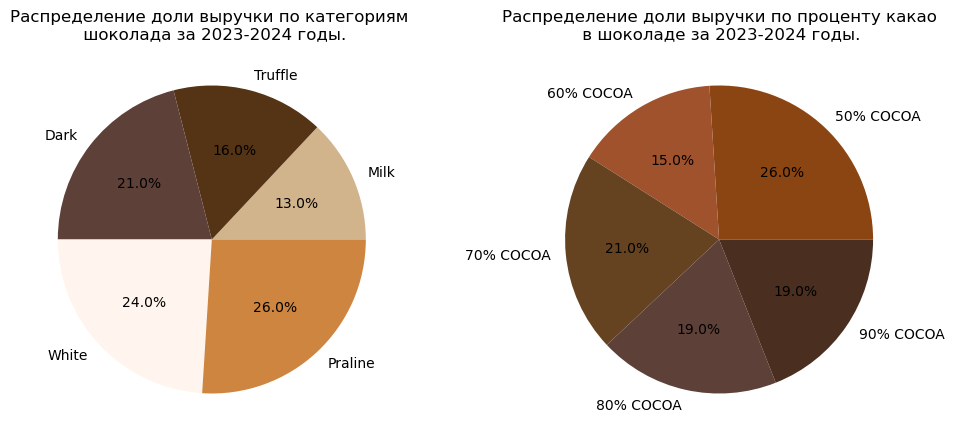

In [16]:
# ГРАФИК 1
# Групируем данные  и вычисляем сумму выручки
category = df.groupby('category').agg(revenue = ('revenue', 'sum'))

# Создаем столбец для расчета доли выручки для каждой категории
category['share'] = round(category['revenue']/category['revenue'].sum(), 2)

# Сортируем данные по столбцу 'share'
category = category.sort_values(by = 'share')

# Создаем словарь с цветами шоколада
colors = {
    'Milk': '#D2B48C',    # Бежевый шоколад
    'Truffle': '#553315', # Глубокий тёмный трюфельный
    'Dark': '#5D4037',    # Классический тёмный шоколад
    'White': '#FFF5EE',   # Молочный белый
    'Praline': '#CD853F'  # Карамельно-ореховый
}

# Получаем цвета для каждого элемента
color = [colors.get(name, 'grey') for name in category.index]

# Визуализация распределения для выборок
plt.figure(figsize=(12, 5))

# Строим круговую диаграмму 1
plt.subplot(1, 2, 1)

plt.pie(category['share'], labels = category.index, autopct='%1.1f%%', colors=color)

# Настраиваем оформление графика
plt.title('Распределение доли выручки по категориям \n шоколада за 2023-2024 годы.')

#-------------------------------------------------------------------------------------

# ГРАФИК 2
# Групируем данные  и вычисляем сумму выручки
cocoa = df.groupby('cocoa_percent').agg(revenue = ('revenue', 'sum'))

# Создаем столбец для расчета доли выручки для каждой категории
cocoa['share'] = round(cocoa['revenue']/cocoa['revenue'].sum(), 2)



# Создаем словарь с цветами шоколада
colors = {
    50: '#8B4513',   # Тёплый коричневый
    60: '#A0522D',   # Сиена
    70: '#654321',   # Классический тёмный шоколад
    80: '#5D4037',   # Горький
    90: '#4A2F20'    # Экстра-горький
}

# Получаем цвета для каждого элемента
color = [colors.get(name, 'grey') for name in cocoa.index]

# Форматируем метки: добавляем  % COCOA к значениям индекса
labels_with_percent = [f'{pct}% COCOA' for pct in cocoa.index]

# Строим круговую диаграмму 2
plt.subplot(1, 2, 2)

plt.pie(cocoa['share'], labels = labels_with_percent, autopct='%1.1f%%', colors=color)

plt.title('Распределение доли выручки по проценту какао\n в шоколаде за 2023-2024 годы.')

plt.show()


Из данного графика распределения выручки мы можем наблюдать, что в совокупной выручке идет иное распределение, по сравнению с прошлым графиком с наименованиями продуктов. Хоть "Dark Chocolate 50%" и "Truffle Chocolate 80%" и занимают лидирующую позицию в топе продуктов, но в категориях продукты, содержащие "Dark" и "Truffle" не являются лидерами. Лидирующие позиции занимают: Praline,  White, Dark, но и какао не влияет всецело на выручку, хоть первое место и совападет (50% какао).

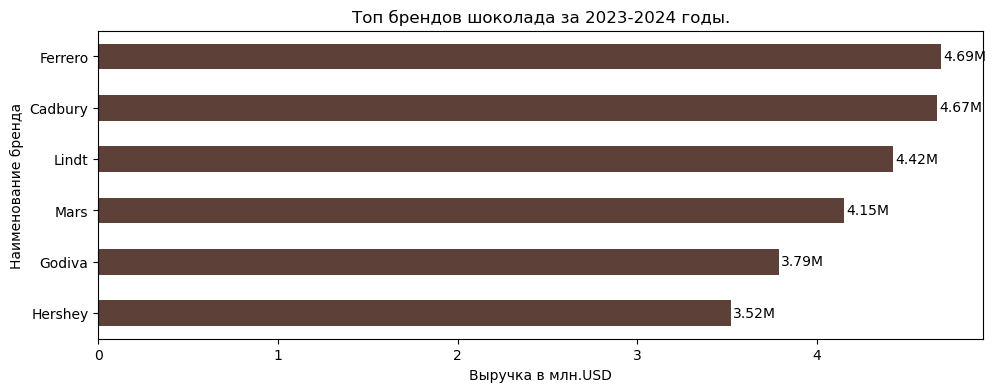

In [17]:
# Групируем данные  вычисляем сумму выручки
product_name = df.groupby('brand').agg(revenue = ('revenue', 'sum'))

# Создаем столбец с выручкой в миллионах
product_name['revenue_m'] = product_name['revenue']/1000000

# Фильтруем данные
product_name = product_name.sort_values(by = 'revenue_m')


# Строим столбчатую диаграмму
ax = product_name['revenue_m'].plot(
    kind='barh',
    color = '#5D4037',
    rot=0,
    legend=False, 
    figsize=(6, 4)
)
# Добавляем подписи 
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(width + 0.01, y, f"{width:,.2f}M", va='center')

# Настраиваем оформление графика
plt.title('Топ брендов шоколада за 2023-2024 годы.')
plt.xlabel('Выручка в млн.USD')
plt.ylabel('Наименование бренда')
plt.subplots_adjust(right=1.6)

plt.show()

Безусловными лидерами рынка являются Ferrero (4,69 млн долларов) и Cadbury (4,67 млн долларов), но также от них не отстает бренд Lindt (4,42 млн долларов). После топ-3 наблюдается более заметное снижение выручки по сравнению с двойкой лидеров:
Mars — 4,15 млн долларов (отставание от Lindt на 0,27 млн);
Godiva — 3,79 млн долларов (отставание от Mars на 0,36 млн);
Hershey — 3,52 млн долларов (отставание от Godiva на 0,27 млн). 
Разница между лидером (Ferrero — 4,69 М) и замыкающим топ-6 брендом (Hershey — 3,52 М) составляет 1,17 млн долларов. Это существенная величина, показывающая, что разрыв между «элитным» и «средним» сегментом топ-6 всё же значителен. Но все бренды демонстрируют выручку выше 3,5 млн долларов, что говорит о высокой рыночной устойчивости участников топ-6.

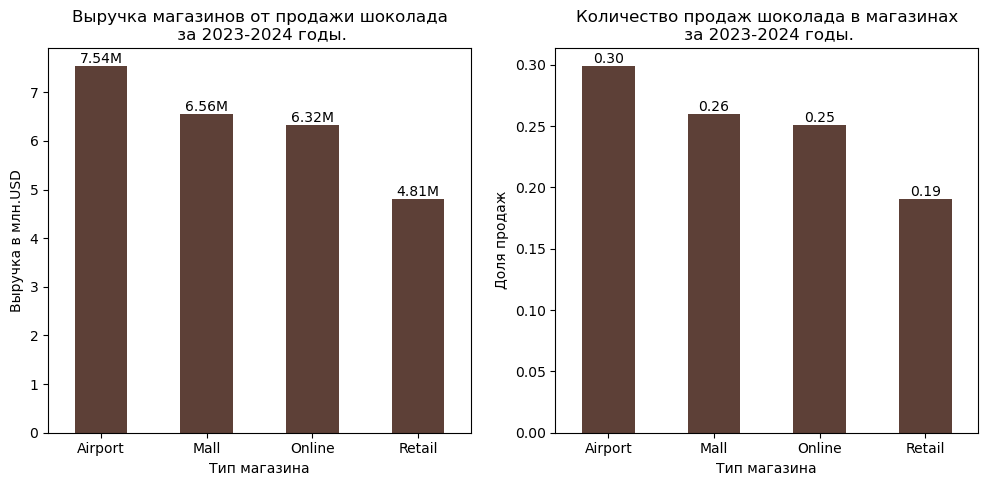

In [18]:
# Групируем данные по 'product_name' и вычисляем сумму выручки
product_name = df.groupby('store_type').agg(revenue = ('revenue', 'sum'),
                                           count = ('quantity', 'sum')
                                           )

# Создаем столбец с выручкой в миллионах
product_name['revenue_m'] = product_name['revenue']/1000000

# Создаем столбец с процентом приобретения товаров
product_name['share'] = product_name['count']/product_name['count'].sum()


# Визуализация 
plt.figure(figsize=(12, 5))

# Строим столбчатую диаграмму 1
plt.subplot(1, 2, 1)

ax = product_name['revenue_m'].plot(
    kind='bar',
    color = '#5D4037',
    rot=0,
    legend=False, 
)

# Добавляем подписи 
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, f'{height:.2f}M', ha='center', va='bottom')

plt.title('Выручка магазинов от продажи шоколада\n за 2023-2024 годы.')
plt.xlabel('Тип магазина')
plt.ylabel('Выручка в млн.USD')

# Строим столбчатую диаграмму 2
plt.subplot(1, 2, 2)

ax = product_name['share'].plot(
    kind='bar',
    color = '#5D4037',
    rot=0,
    legend=False, 
)

# Добавляем подписи 
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

plt.title('Количество продаж шоколада в магазинах\n за 2023-2024 годы.')
plt.xlabel('Тип магазина')
plt.ylabel('Доля продаж')

plt.show()


На графиках выше можно наблюдать, что лидером по продажам является Аэропорт с большим отрывом в почти 1 млн.USD. Можно предположить, что шоколад является популярным видом перекуса в дороге.

In [19]:
# Группируем и агрегируем
pivot = df.groupby('city').agg(
    total_orders = ('order_id', 'count'),
    total_quantity = ('quantity', 'sum'),
    total_revenue = ('revenue', 'sum'),
    revenue_mean = ('revenue', 'mean'),
    revenue_median = ('revenue', 'median'),
    revenue_max = ('revenue', 'max')
    ).sort_values(by = 'total_orders', ascending = False)


display(
    pivot.style
    .format({'total_revenue': '{:.2f}', 'revenue_mean': '{:.2f}', 'revenue_median': '{:.2f}', 'revenue_max': '{:.2f}'})  # форматируем нужные столбцы
    .background_gradient(cmap='YlOrRd')  # добавляем градиент
)

,total_orders,total_quantity,total_revenue,revenue_mean,revenue_median,revenue_max
city,,,,,,
Toronto,178375,535085,4548215.00,25.50,21.90,75.00
Paris,157992,473132,4010580.25,25.38,21.80,75.00
London,157857,473306,4023252.25,25.49,21.88,75.00
New York,149020,447849,3804075.00,25.53,22.00,75.00
Sydney,129057,387005,3290556.25,25.50,21.94,75.00
Melbourne,118684,355875,3028464.25,25.52,21.96,75.00
Berlin,99251,298218,2533505.50,25.53,22.00,75.00


Можно наблюдать, что распределение количества заказов, количества товаров и выручки ровное, нет разрозненности, что в каком то городе было продано больше товаров, а выручки получено меньше.
А вот среденняя и медианная выручка уже не исключительная принадлежность лидеров. Например Berlin при низком количестве заказов(99251) и выручке(2533505.50) по сравнению с другими городами, является лидером по средней выручке(25.53) и медианной(22.00).
Кроме того есть разница между медианой и средней около 3-4 USD, а максимальное значение выручки находится на отметке в 75 USD, что говорит о влиянии выбросов. 

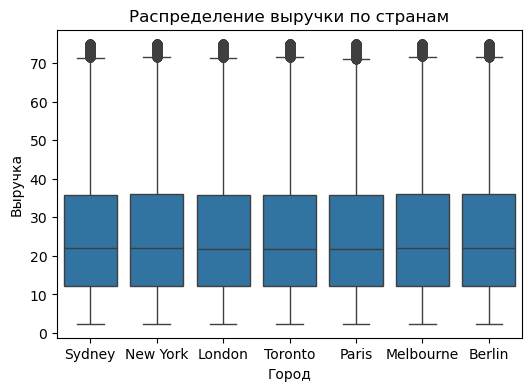

In [20]:
# Создаем boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='city', y='revenue')

# Улучшаем читаемость подписей
plt.title('Распределение выручки по странам')
plt.xlabel('Город')
plt.ylabel('Выручка')

plt.show()

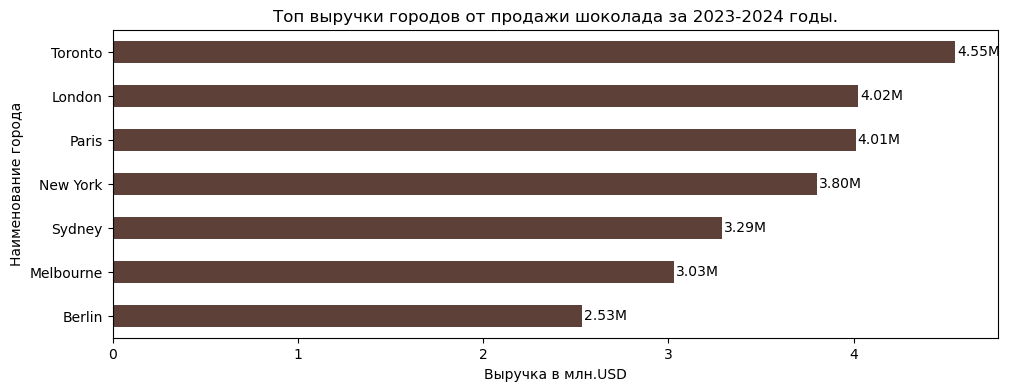

In [21]:
# Группируем данные о выручке по стране
group = df.groupby('city').agg(revenue = ('revenue', 'sum'))

# Создаем столбец с выручкой в миллионах
group['revenue_m'] = group['revenue']/1000000

# Фильтруем данные
group = group.sort_values(by = 'revenue_m')

# Строим столбчатую диаграмму
ax = group['revenue_m'].plot(
    kind='barh',
    color = '#5D4037',
    rot=0,
    legend=False, 
    figsize=(6, 4)
)
# Добавляем подписи 
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(width + 0.01, y, f"{width:,.2f}M", va='center')

# Настраиваем оформление графика
plt.title('Топ выручки городов от продажи шоколада за 2023-2024 годы.')
plt.xlabel('Выручка в млн.USD')
plt.ylabel('Наименование города')
plt.subplots_adjust(right=1.6)
plt.show()

Между большинством городов наблюдается существенная разница в получении выручки магазинами.

<a id='section1'></a>
### 4. Выводы

Типичным портретом клиента является:
 * Пол: женщина и мужчина почти в равной мере, но больше покупателей мужского пола на 1 %,
 * Возраст: мужчина 40 лет или женщина 38 лет, но ярко выраженного возраста клиента, который бы покупол шоколод нет.
 * Предпочтения: 
    - клиенты предпочитают шоколад "Dark Chocolate 50%" и "Truffle Chocolate 80%", 
    - при этом топом категории шоколада являются "Praline" (26% клиентов), "White" (24% клиентов), "Dark" (21% клиентов), 
    - а по содержанию какао в шоколаде предпочтение отдается 50% COCOA (26% клиентов) и 70% COCOA (21% клиентов),
    - брендами занимающими лидирующие позиции по выручке являются Ferrero (4,69 млн долларов), Cadbury(4,67 млн долларов), Lindt(4,42 млн долларов),
    - чаще всего клиенты предпочитают покупать шоколад в Аэропортах (30%), а далее в торговых центрах (26%), онлайн (25%) и уже потом в иных местах покупки (19%).
    - предпочтительным, наиболее часто встречаемым ценником для покупки является заказ на сумму 22 USD.
 * городами, в которых чаще всего совершаются покупки шоколада и приносящие, больше всего выручки являются: Toronto (4.55 млн.USD), London (4.02 млн.USD), Paris (4.01 млн.USD)

***По итогам анализа:***

* Аудитория почти гендерно‑сбалансирована — маркетинговые кампании стоит ориентировать на обе группы без сильного уклона.
* Оптимальный ассортимент должен включать Praline и White Chocolate, а также позиции с содержанием какао 50–70 %.
* Приоритетные каналы продаж: аэропорты (лидер), торговые центры и онлайн.
* Целевые города для продвижения и расширения присутствия: Торонто, Лондон, Париж, при этом стоит рассмотреть причины, что могло снизить выручку в других городах, как Berlin (2,53 млн долларов).
* Ценовое позиционирование целесообразно выстраивать вокруг отметки 22 USD за заказ.
